In [2]:
import pyrtl
from pyrtl.rtllib.adders import *
from IPython.display import display_svg

In [4]:
import pyrtl.rtllib.libutils as rtlutils

x = int('00011000',2)

format(rtlutils.twos_comp_repr(-56, 8) , '08b')
result = format(rtlutils.twos_comp_repr(-56+x, 8) , '08b')
result

'11100000'

In [ ]:
len('101000001000000')

15

In [5]:
def get_const_offset(e_bits, m_bits):
    total_bits = e_bits + m_bits
    bias = (2**(e_bits-1) - 1) << m_bits
    
    if m_bits <= 3:
        l = m_bits
    if m_bits == 4:
        l = 3
    if m_bits > 4:
        l = 4
    l = (1 << m_bits) >> l
    
    offset = rtlutils.twos_comp_repr(l-bias, total_bits)
    return offset
    
e4m3offset = get_const_offset(4,3)
print(e4m3offset)
print(format(e4m3offset, '0b'))

# Result in bounds
print("Normal case:")
result = e4m3offset + int('1111000',2)
result = format(result, '09b')
print(result, len(result))

# Result underflow
print("\nUnderflow case:")
result = e4m3offset + int('0001001',2)
result = format(result, '09b')
print(result, len(result))

# Result overflow
print("\nOverflow case:")
result = e4m3offset + int('11000000',2)
result = format(result, '09b')
print(result, len(result))


### Output
# Normal case:
# 011000001 9

# Underflow case:
# 001010010 9

# Overflow case:
# 100001001 9

73
1001001
Normal case:
011000001 9

Underflow case:
001010010 9

Overflow case:
100001001 9


In [144]:
(format(0b1111111 + 0b1111111, '0b'))

'11111110'

In [ ]:
len('101000001000000')

15

In [111]:
format(0b1111*2, '0b')

'11110'

In [85]:
len('101000001000000')

15

## $Lmul$ Implementation in PyRTL


In [168]:
pyrtl.reset_working_block()

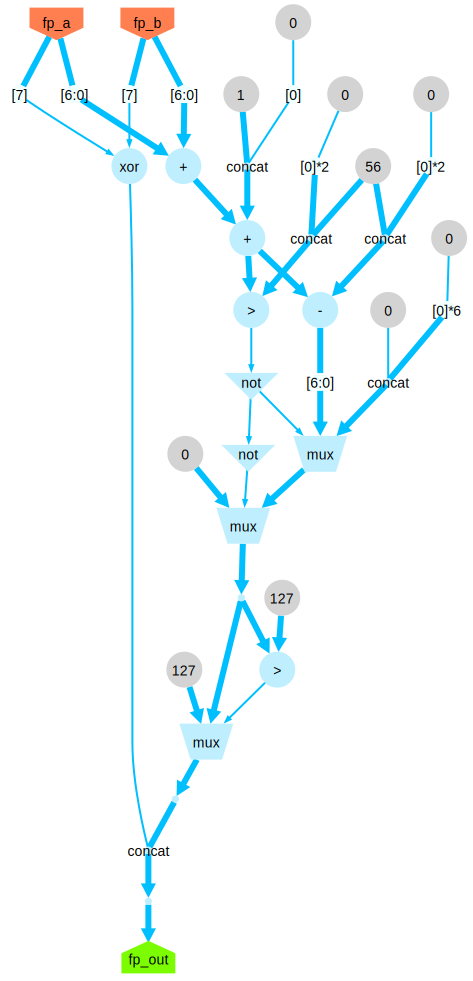

Pre Optimization:
The total block timing delay is  5323.350000000002
Post Optimization:
The total block timing delay is  2579.1699999999996


In [22]:
def lmul_hardware0():
    # Input/Output declarations
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split inputs into sign, exponent and mantissa
    sign_a = fp_a[7]
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]  # bits 0-6
    exp_mantissa_b = fp_b[0:7]  # bits 0-6

    # Calculate result sign using XOR
    result_sign = sign_a ^ sign_b

    # For E4M3 format:
    # - 4 exponent bits means bias of 7 (2^(4-1)-1)
    # - L(3) = 3 since mantissa bits <= 3
    # - Bias needs to be shifted left by mantissa bits (3) = 7 << 3 = 56
    BIAS_SHIFTED = pyrtl.Const(56, 7)  # 7 << 3 = 56 (0b0111000)
    L_OFFSET = pyrtl.Const(1, 7)  # L(3) = 3

    # Add exponents and mantissas together
    exp_mantissa_sum = exp_mantissa_a + exp_mantissa_b 

    # Add L(M) offset
    sum_with_offset = exp_mantissa_sum + L_OFFSET

    # Subtract bias
    result = pyrtl.WireVector(7)
    with pyrtl.conditional_assignment:
        with sum_with_offset >= BIAS_SHIFTED:
            result |= sum_with_offset - BIAS_SHIFTED
        with pyrtl.otherwise:
            result |= 0

    # Clamp to max value (0x7F = 127)
    clamped_result = pyrtl.WireVector(7)
    clamped_result <<= pyrtl.select(result > 0x7F, truecase=0x7F, falsecase=result)

    # Combine sign and result 
    fp_out <<= pyrtl.concat(result_sign, clamped_result)
    return fp_out

pyrtl.reset_working_block()
fp_out = lmul_hardware0()

svg = pyrtl.block_to_svg()
display_svg(svg, raw=True)

pyrtl.synthesize()

print("Pre Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

pyrtl.optimize()

print("Post Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

### Attempt 2


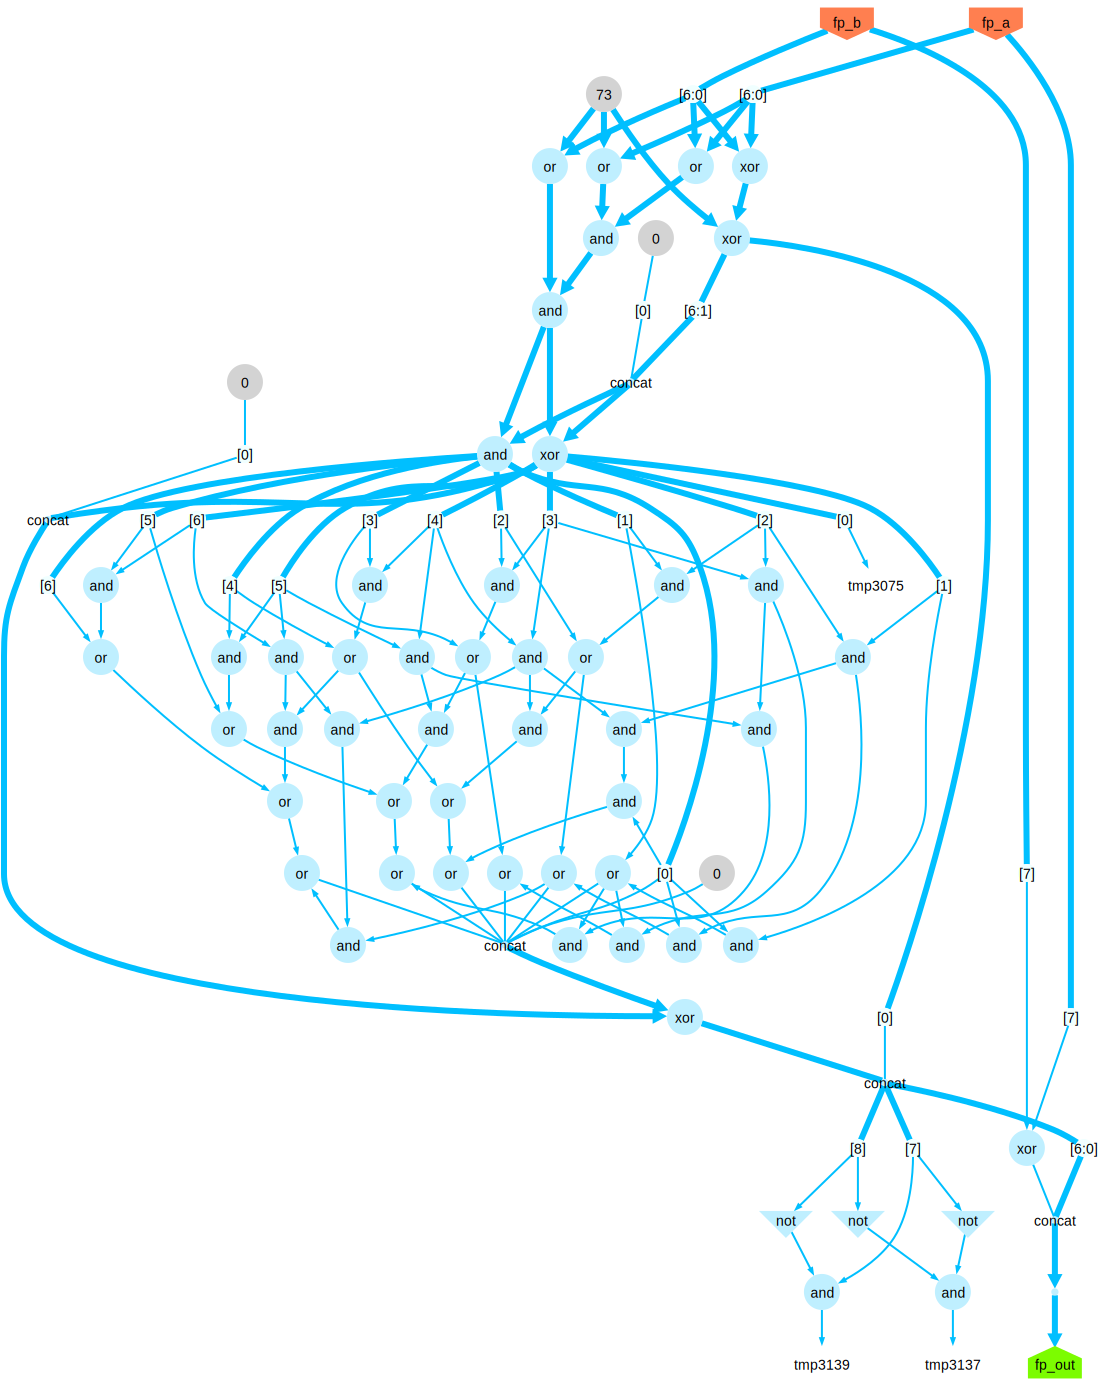

In [31]:
def lmul_hardware2():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split into sign and exp_mantissa parts
    sign_a = fp_a[7] 
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]
    exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = sign_a ^ sign_b

    # Add exp_mantissa parts using kogge_stone adder (faster than ripple)
    # exp_mantissa_sum = kogge_stone(exp_mantissa_a, exp_mantissa_b)
    
    # For E4M3: e_bits=4, m_bits=3
    # Get the combined offset-bias constant 
    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    
    # Add offset-bias value - this will be 8 bits including carry
    # final_sum = kogge_stone(exp_mantissa_sum, OFFSET_MINUS_BIAS)
    
    final_sum = carrysave_adder(exp_mantissa_a, exp_mantissa_b, OFFSET_MINUS_BIAS, final_adder=kogge_stone)
    
    # Extract carry and MSB for overflow/underflow detection
    carry = final_sum[8]  # 9th bit
    msb = final_sum[7]    # 8th bit
    result_bits = final_sum[0:7]  # lower 7 bits

    # Select result based on carry and MSB:
    # carry=1: overflow -> 0x7F
    # carry=0, msb=0: underflow -> 0x00
    # carry=0, msb=1: normal -> result_bits
    MAX_VALUE = pyrtl.Const(0x7F, 7)
    
    with pyrtl.conditional_assignment:
        with carry:
            mantissa_result = MAX_VALUE
        with ~carry & ~msb:
            mantissa_result = 0
        with ~carry & msb:
            mantissa_result = result_bits

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

# Create the hardware
pyrtl.reset_working_block()
fp_a, fp_b, fp_out = lmul_hardware2()

svg = pyrtl.block_to_svg(maintain_arg_order=True)
display_svg(svg, raw=True)

In [24]:
# Set up simulation
sim_trace = pyrtl.SimulationTrace()
sim = pyrtl.Simulation(tracer=sim_trace)

# Test vectors - let's test normal, overflow and underflow cases
test_vectors = [
    # Normal case: two small numbers
    (0x40, 0x40),  # inputs have exponent=4, mantissa=0
    
    # Overflow case: two large numbers
    (0x70, 0x70),  # inputs have large exponents
    
    # Underflow case: two small numbers
    (0x01, 0x01),  # inputs have very small values
    
    # Mixed signs
    (0xC0, 0x40),  # negative * positive
]

# Run simulation
for a, b in test_vectors:
    sim.step({
        'fp_a': a,
        'fp_b': b
    })

# Print the results
sim_trace.render_trace()

# You can also print specific values
print("\nDetailed Results:")
for i, (a, b) in enumerate(test_vectors):
    result = sim_trace.trace['fp_out'][i]
    print(f"fp_a: {format(a, '08b')} * fp_b: {format(b, '08b')} = fp_out: {format(result, '08b')}")

<IPython.core.display.Javascript object>


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 01110000 * fp_b: 01110000 = fp_out: 00101001
fp_a: 00000001 * fp_b: 00000001 = fp_out: 01001011
fp_a: 11000000 * fp_b: 01000000 = fp_out: 11001001


In [25]:
# Generating timing analysis information
print("Pre Synthesis:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=18)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

Pre Synthesis:
The total block timing delay is  1232.34
Estimated Area of block 2.338321420118343e-05 sq mm



In [26]:
pyrtl.synthesize()

print("Pre Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
for net in pyrtl.working_block().logic:
    print(str(net))
print()

pyrtl.optimize()

print("Post Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

Pre Optimization:
The total block timing delay is  1232.34
tmp1789\_synth\_6/1W & \leftarrow w \, - & tmp\_fp\_b\_synth\_6/1W  \\
tmp1969/1W & \leftarrow \oplus \, - & tmp1791\_synth\_2/1W, const\_212\_73\_synth\_2/1C  \\
tmp1872/1W & \leftarrow s \, - & fp\_b/8I ((4,)) \\
tmp1985/1W & \leftarrow \& \, - & tmp1800\_synth\_4/1W, tmp1797\_synth\_4/1W  \\
tmp1901/1W & \leftarrow \oplus \, - & tmp1788\_synth\_3/1W, tmp1789\_synth\_3/1W  \\
tmp\_fp\_out\_synth\_3/1W & \leftarrow w \, - & tmp1867\_synth\_3/1W  \\
tmp1796\_synth\_4/1W & \leftarrow w \, - & tmp1939/1W  \\
tmp1827\_synth\_0/1W & \leftarrow w \, - & tmp1893/1W  \\
tmp1928/1W & \leftarrow \| \, - & tmp1811\_synth\_0/1W, tmp1832\_synth\_0/1W  \\
tmp1801\_synth\_3/1W & \leftarrow w \, - & tmp1916/1W  \\
tmp1820\_synth\_0/1W & \leftarrow w \, - & tmp1978/1W  \\
tmp1980/1W & \leftarrow \& \, - & tmp1836\_synth\_0/1W, tmp1846\_synth\_0/1W  \\
tmp1963/1W & \leftarrow \oplus \, - & tmp1853\_synth\_5/1W, tmp1855\_synth\_5/1W  \\
tmp1869/

### Attempt 3


Pre Optimization:
The total block timing delay is  3444.540000000001
Post Optimization:
The total block timing delay is  2868.04


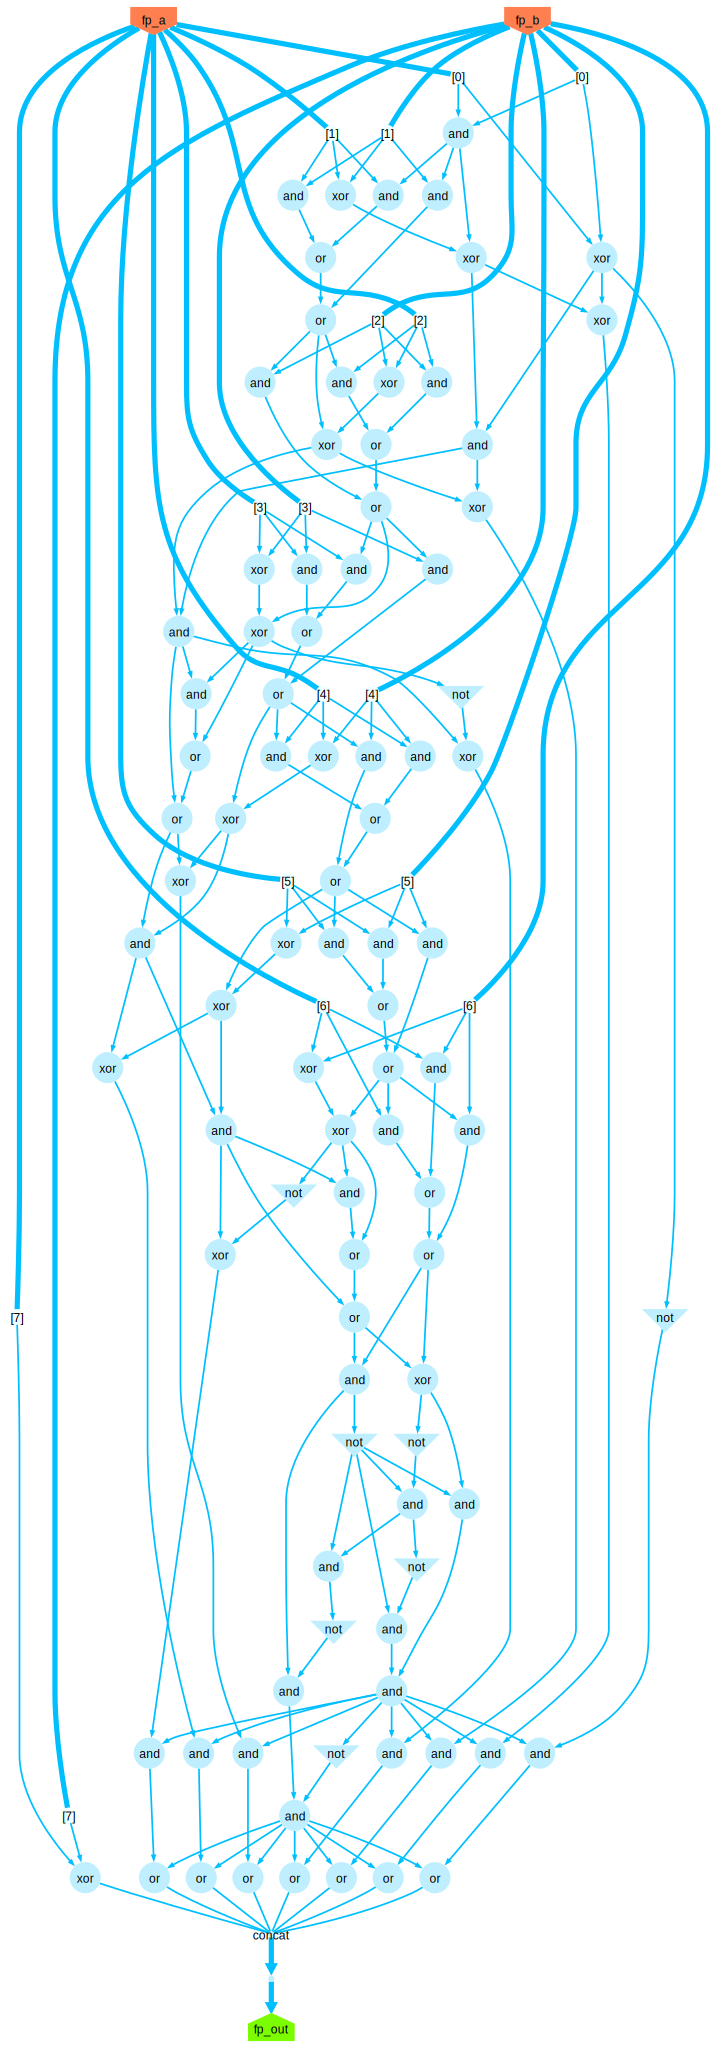

In [27]:
def lmul_hardware3():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split into sign and exp_mantissa parts
    sign_a = fp_a[7] 
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]
    exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = sign_a ^ sign_b

    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    
    final_sum = exp_mantissa_a + exp_mantissa_b + OFFSET_MINUS_BIAS
    mantissa_result = pyrtl.WireVector(7, 'mantissa_result')
    # Extract carry and MSB for overflow/underflow detection
    carry = final_sum[8]  # 9th bit
    msb = final_sum[7]    # 8th bit
    result_bits = final_sum[0:7]  # lower 7 bits

    MAX_VALUE = pyrtl.Const(0x7F, 7)
    
    with pyrtl.conditional_assignment:
        with final_sum[8]:
            mantissa_result |= MAX_VALUE
        with ~final_sum[8] & ~final_sum[7]:
            mantissa_result |= 0
        with ~final_sum[8] & final_sum[7]:
            mantissa_result |= final_sum[0:7]

    # # Extract carry and MSB for overflow/underflow detection
    # carry = final_sum[8]  # 9th bit
    # msb = final_sum[7]    # 8th bit
    # result_bits = final_sum[0:7]  # lower 7 bits

    # MAX_VALUE = pyrtl.Const(0x7F, 7)
    
    # with pyrtl.conditional_assignment:
    #     with carry:
    #         mantissa_result = MAX_VALUE
    #     with ~carry & ~msb:
    #         mantissa_result = 0
    #     with ~carry & msb:
    #         mantissa_result = result_bits


    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

# Create the hardware
pyrtl.reset_working_block()
fp_a, fp_b, fp_out = lmul_hardware3()

pyrtl.synthesize()

print("Pre Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

pyrtl.optimize()

print("Post Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

svg = pyrtl.block_to_svg(maintain_arg_order=True)
display_svg(svg, raw=True)

Pre Optimization:
The total block timing delay is  2889.9400000000005
Post Optimization:
The total block timing delay is  1962.6399999999996


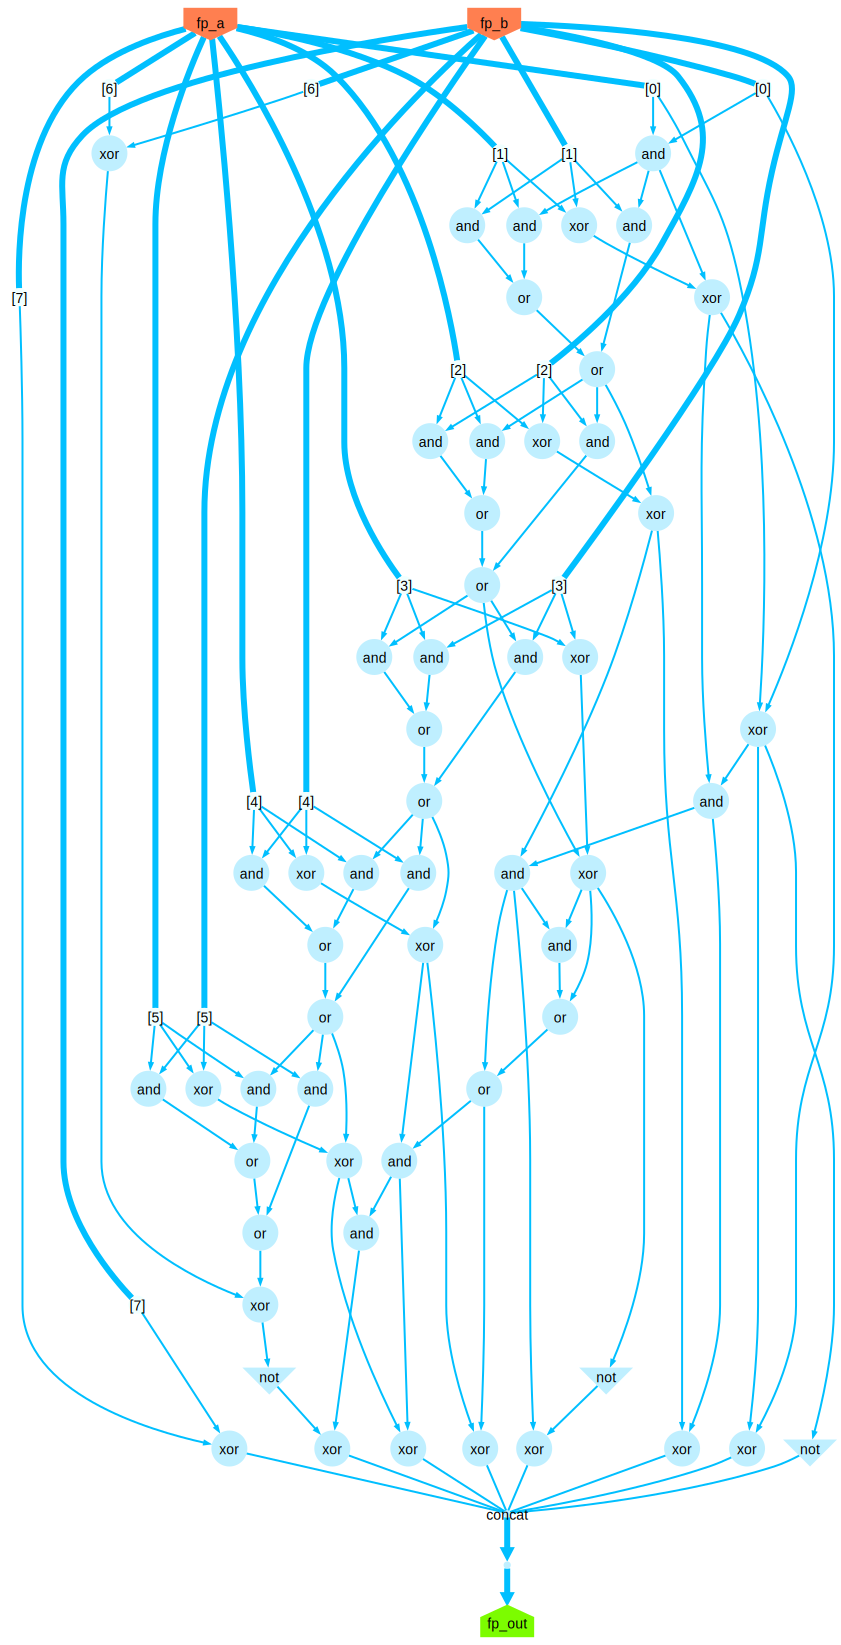

In [30]:
def lmul_hardware3():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split into sign and exp_mantissa parts
    sign_a = fp_a[7] 
    sign_b = fp_b[7]
    exp_mantissa_a = fp_a[0:7]
    exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = sign_a ^ sign_b

    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    
    final_sum = exp_mantissa_a + exp_mantissa_b + OFFSET_MINUS_BIAS
    # mantissa_result = pyrtl.WireVector(7, 'mantissa_result')
    # Extract carry and MSB for overflow/underflow detection
    carry = final_sum[8]  # 9th bit
    msb = final_sum[7]    # 8th bit
    # result_bits = final_sum[0:7]  # lower 7 bits

    MAX_VALUE = pyrtl.Const(0x7F, 7)
    
    with pyrtl.conditional_assignment:
        with carry:
            mantissa_result = MAX_VALUE
        with ~carry & ~msb:
            mantissa_result = 0
        with ~carry & msb:
            mantissa_result = final_sum[0:7]


    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

# Create the hardware
pyrtl.reset_working_block()
fp_a, fp_b, fp_out = lmul_hardware3()

pyrtl.synthesize()

print("Pre Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

pyrtl.optimize()

print("Post Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()

svg = pyrtl.block_to_svg(maintain_arg_order=True)
display_svg(svg, raw=True)